{'topic': '猫咪', 'poem': AIMessage(content='## 《猫》\n\n你如此轻咬我的食指\n像触碰水晶杯沿的橘色黄昏\n尾巴扫过琴键\n留下渐弱的颤音\n\n你伏在我的膝弯里\n铺开一片微醺的腹地\n伸展，骨节里藏着\n未被驯服的雪\n\n当眼眸溢出金辉\n瞳仁中尽是深邃的洞穴\n映出童年阁楼里\n练习折纸飞机的夏天\n\n我抚摸你\n沉醉于这迷人的存在\n你是个小小的星球\n自转着柔和的暖\n\n你的呼吸匀速地\n煮着一壶未满的茉莉香\n你翻身，露出的肚皮\n静止了时间\n\n这足以让我遗忘\n隔着窗玻璃消散的\n所有蝉鸣，所有雨滴\n和遗落在纽扣里的雪\n\n这片刻即足够\n让我忘记被扰乱的睡眠\n和每件半途而废的事\n被你踩碎的月光', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 189, 'prompt_tokens': 10, 'total_tokens': 199, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 10}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '1dd47bc4-e657-47e7-9e2e-bd9392764d60', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f9d55-1d52-7562-8f68-c1ce29668d37-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10

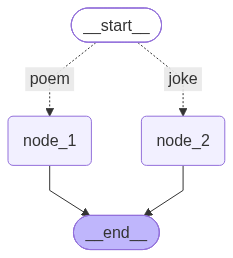

: 

In [ ]:
# -*- coding: utf-8 -*-
# 【CP2-03 路径映射】path_map 将抽象路由键映射到真实节点名，实现解耦
# 文件：CP2/03_path_map.ipynb
# 作用：本 Cell 演示 【CP2-03 路径映射】path_map 将抽象路由键映射到真实节点名，实现解耦 的完整可运行示例
# 阅读顺序：状态定义 → 节点定义 → 图构建 → 编译执行 → 结果观察

from dotenv import load_dotenv
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph,START,END    
from typing import TypedDict, Annotated,Literal
load_dotenv()

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body={        
        "thinking":{
            "type":"disabled"
        }
    }
)

# 1 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

def node_1(state : OverAllState) -> OverAllState:
    # 向全局状态添加poem
    return {
        "poem": model.invoke(f"请写一首关于{state['topic']}的诗"),  # AND 汇合：需全部前驱完成才触发下游
    }

def node_2(state : OverAllState) -> OverAllState:
    # 向全局状态添加joke
    return {
        "joke": model.invoke(f"请写一个关于{state['topic']}的笑话"),  # AND 汇合：需全部前驱完成才触发下游
    }

# 添加路由
def my_route(state : OverAllState) -> Literal["poem", "joke"]:
    # 根据topic判断是否需要路由
    if "诗" in state["content_type"]:
        return "poem"
    else:
        return "joke"

# 2 构建状态图
builder = StateGraph(state_schema=OverAllState)  # 创建状态图构建器：绑定状态 Schema
builder.add_node("node_1", node_1)  # 注册节点到图中
builder.add_node("node_2", node_2)  # 注册节点到图中
builder.add_conditional_edges(  # 条件边 + path_map：路由键与节点名解耦
    START,my_route,path_map={
        "poem":"node_1",
        "joke":"node_2"
        }
    )
builder.add_edge("node_1", END)  # 汇入终点
builder.add_edge("node_2", END)  # 汇入终点

graph = builder.compile()  # 编译图：蓝图→可执行对象

result1 = graph.invoke({"topic": "猫咪","content_type":"诗"})  # 触发图执行：传入初始 State + config
print(result1)

result2 = graph.invoke({"topic": "猫咪","content_type":"笑话"})  # 触发图执行：传入初始 State + config
print(result2)


from IPython.display import display
display(graph)
